In [1]:
import numpy as np
print("ready!")

ready!


In [2]:
import numpy as np

# Q-table: 2 states x 2 actions
# State: electricity price (0=low, 1=high)
# Action: 0=do not generate, 1=generate

Q = np.zeros((2, 2))

print("Initial Q-table:")
print(Q)
print("Rows = states (0=low price, 1=high price)")
print("Cols = actions (0=do not generate, 1=generate)")

Initial Q-table:
[[0. 0.]
 [0. 0.]]
Rows = states (0=low price, 1=high price)
Cols = actions (0=do not generate, 1=generate)


In [4]:
def get_reward(state, action):
    # state 0 = low price, state 1 = high price
    # action 0 = do not generate, action 1 = generate
    if state == 1 and action == 1:
        return 10   # high price + generate = big profit
    elif state == 0 and action == 1:
        return -5   # low price + generate = loss
    else:
        return 0    # do not generate = neutral

In [5]:
print(get_reward(1, 1))  # high price, generate
print(get_reward(0, 1))  # low price, generate
print(get_reward(0, 0))  # low price, do not generate

10
-5
0


In [6]:
# training settings
learning_rate = 0.1
gamma = 0.9
episodes = 1000

# training loop
for episode in range(episodes):
    state = np.random.randint(0, 2)  # random state: 0 or 1
    
    # choose action: sometimes random, sometimes use Q-table
    if np.random.rand() < 0.1:
        action = np.random.randint(0, 2)  # explore
    else:
        action = np.argmax(Q[state])      # exploit
    
    reward = get_reward(state, action)
    
    # update Q-table
    Q[state, action] = Q[state, action] + learning_rate * (reward - Q[state, action])

print("Trained Q-table:")
print(Q)

Trained Q-table:
[[ 0.         -4.60116778]
 [ 0.         10.        ]]


In [9]:
df = pd.read_csv("Gro_handelspreise2024_Stunde.csv", sep=";", decimal=",", encoding="utf-8-sig")
print(df.head())
print(df.shape)

          Datum von         Datum bis  \
0  01.01.2024 00:00  01.01.2024 01:00   
1  01.01.2024 01:00  01.01.2024 02:00   
2  01.01.2024 02:00  01.01.2024 03:00   
3  01.01.2024 03:00  01.01.2024 04:00   
4  01.01.2024 04:00  01.01.2024 05:00   

   Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen  \
0                                               0.10      
1                                               0.01      
2                                               0.00      
3                                              -0.01      
4                                              -0.03      

   ∅ Anrainer DE/LU [€/MWh] Berechnete Auflösungen  \
0                                            21.15   
1                                            20.96   
2                                            17.73   
3                                            14.59   
4                                            14.23   

   Belgien [€/MWh] Berechnete Auflösungen  \
0                           

In [10]:
# extract Germany price column
price_col = "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"
prices = df[price_col].values

print(f"Total hours: {len(prices)}")
print(f"Min price: {prices.min():.2f} €/MWh")
print(f"Max price: {prices.max():.2f} €/MWh")
print(f"Mean price: {prices.mean():.2f} €/MWh")

Total hours: 8784
Min price: -135.45 €/MWh
Max price: 936.28 €/MWh
Mean price: 78.51 €/MWh


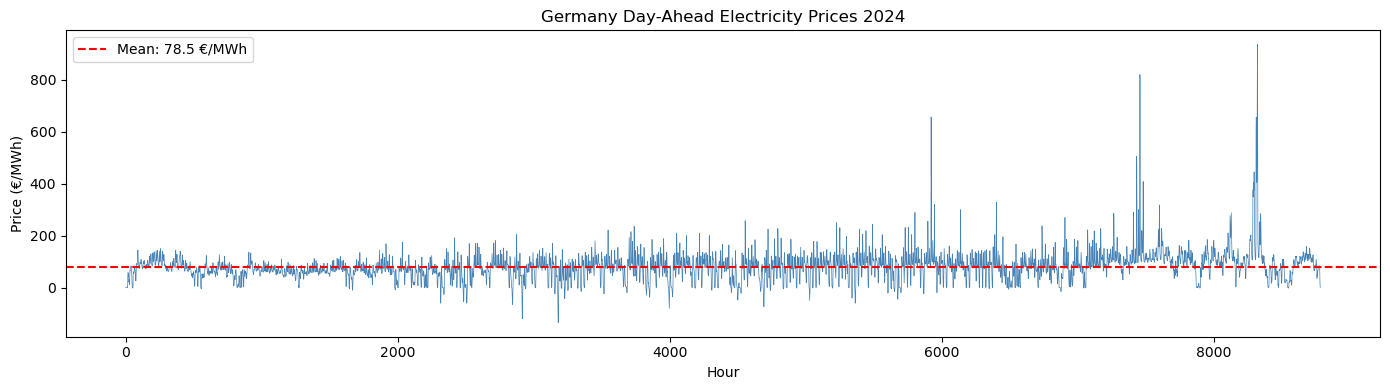

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(prices, linewidth=0.5, color="steelblue")
plt.axhline(y=prices.mean(), color="red", linestyle="--", label=f"Mean: {prices.mean():.1f} €/MWh")
plt.title("Germany Day-Ahead Electricity Prices 2024")
plt.xlabel("Hour")
plt.ylabel("Price (€/MWh)")
plt.legend()
plt.tight_layout()
plt.savefig("prices_2024.png", dpi=150)
plt.show()

In [13]:
# define threshold: high price = above mean
threshold = prices.mean()

# Q-table: 2 states x 2 actions
# state 0 = low price (below mean)
# state 1 = high price (above mean)
Q_real = np.zeros((2, 2))

# OCGT parameters
start_cost = 50      # €/MWh cost to generate (fuel + startup)
learning_rate = 0.1
episodes = 5

for episode in range(episodes):
    total_reward = 0
    
    for price in prices:
        # define state
        state = 1 if price > threshold else 0
        
        # choose action
        if np.random.rand() < 0.1:
            action = np.random.randint(0, 2)
        else:
            action = np.argmax(Q_real[state])
        
        # calculate reward
        if action == 1:  # generate
            reward = price - start_cost
        else:
            reward = 0
        
        # update Q-table
        Q_real[state, action] = Q_real[state, action] + learning_rate * (reward - Q_real[state, action])
        total_reward += reward
    
    print(f"Episode {episode+1}: Total reward = €{total_reward:,.0f}")

print("\nFinal Q-table:")
print(Q_real)

Episode 1: Total reward = €268,786
Episode 2: Total reward = €270,482
Episode 3: Total reward = €267,621
Episode 4: Total reward = €271,628
Episode 5: Total reward = €264,709

Final Q-table:
[[ 0.         -1.86857933]
 [ 0.         37.33412383]]


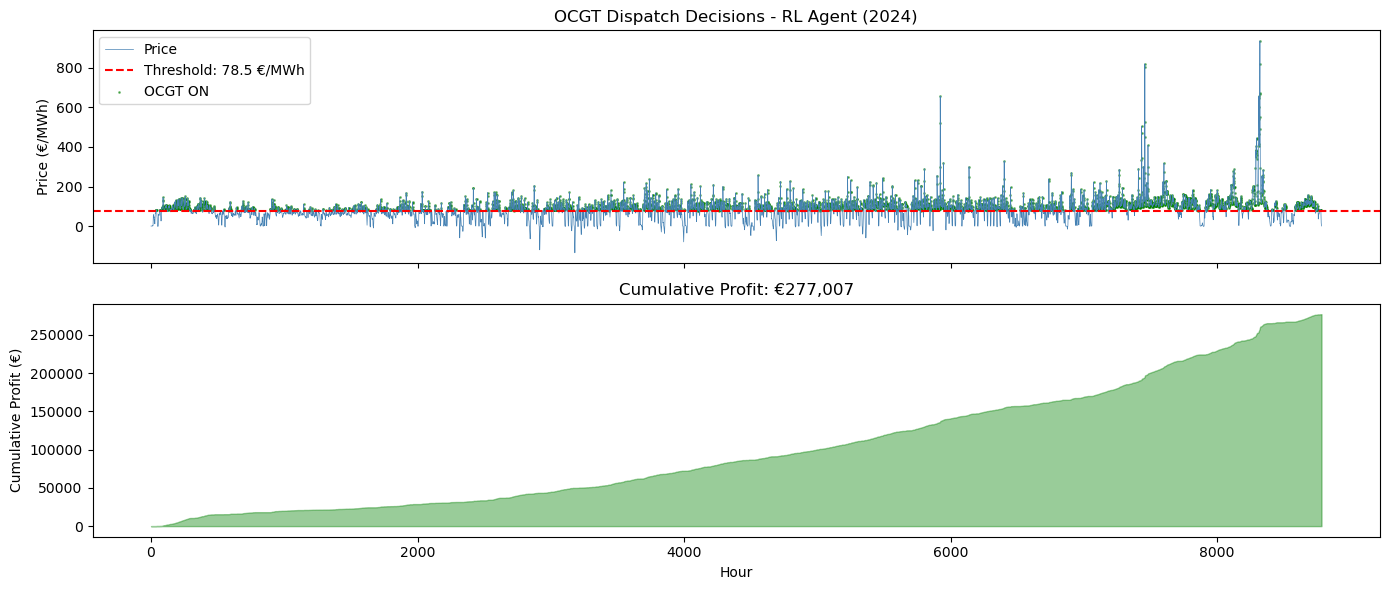

In [14]:
# simulate agent decisions on full year
decisions = []
rewards = []

for price in prices:
    state = 1 if price > threshold else 0
    action = np.argmax(Q_real[state])  # no exploration, pure exploitation
    
    if action == 1:
        reward = price - start_cost
    else:
        reward = 0
    
    decisions.append(action)
    rewards.append(reward)

decisions = np.array(decisions)
rewards = np.array(rewards)

# plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(prices, linewidth=0.5, color="steelblue", label="Price")
ax1.axhline(y=threshold, color="red", linestyle="--", label=f"Threshold: {threshold:.1f} €/MWh")
ax1.scatter(np.where(decisions==1)[0], prices[decisions==1], 
            color="green", s=1, label="OCGT ON", alpha=0.5)
ax1.set_ylabel("Price (€/MWh)")
ax1.legend()
ax1.set_title("OCGT Dispatch Decisions - RL Agent (2024)")

ax2.fill_between(range(len(rewards)), np.cumsum(rewards), color="green", alpha=0.4)
ax2.set_ylabel("Cumulative Profit (€)")
ax2.set_xlabel("Hour")
ax2.set_title(f"Cumulative Profit: €{sum(rewards):,.0f}")

plt.tight_layout()
plt.savefig("rl_agent_result.png", dpi=150)
plt.show()